# Vector Quantization and Residual Vector Quantization: Results

This notebook demonstrates the reconstruction quality of two discrete representation learning systems trained on MNIST:

- **VQ-VAE**: Single vector quantizer with one codebook
- **RVQ-VAE**: Residual vector quantization with multiple codebooks in cascade

Both use the same convolutional encoder/decoder architecture. The quantizer sits at the bottleneck, compressing each spatial position of the latent representation to a discrete codebook index.

The core question: how does stacking quantizers in residual fashion improve reconstruction quality, and what does each stage contribute?

## 0. Imports and Setup

In [40]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import sys
import os

# add parent directory to path so we can import our modules
sys.path.append(os.path.dirname(os.path.abspath('')))

from autoencoder import VQAE, RVQAE

# paths to checkpoints -- update if needed
VQ_CHECKPOINT = 'checkpoint_epoch_10.pt'
RVQ_CHECKPOINT = 'checkpoints/checkpoint_epoch_9_RVQ.pt'
MNIST_PATH = r'C:\Users\yotam\Documents\University\self learning\Phoneme Hallucination optimization\codec gradient analysis'

# load a small batch of MNIST for visualization
loader = DataLoader(
    datasets.MNIST(MNIST_PATH, download=False, transform=transforms.ToTensor()),
    batch_size=64, shuffle=True
)
sample_x, sample_y = next(iter(loader))
sample_x = sample_x[:8]  # 8 images for visualization

print(f'Sample batch shape: {sample_x.shape}')

Sample batch shape: torch.Size([8, 1, 28, 28])


## 1. Single VQ-VAE

The VQ-VAE compresses each 7x7 spatial position of the encoder output (64-dimensional) to the nearest entry in a codebook of 512 vectors. The codebook is learned jointly with the encoder and decoder.

At the bottleneck, the 28x28 input image is represented by 49 discrete integers (7x7 positions), each indexing one of 512 possible 64-dimensional vectors. This is an extreme compression -- the entire image content is described by 49 integers.

Two training losses drive the codebook:
- **Commitment loss**: pushes encoder outputs toward codebook entries
- **Codebook loss**: pushes codebook entries toward encoder outputs

The straight-through estimator (STE) passes reconstruction gradients back through the non-differentiable argmin operation.

In [41]:
# load VQ model
vq_model = VQAE()
checkpoint = torch.load(VQ_CHECKPOINT, map_location='cpu')
vq_model.load_state_dict(checkpoint['model_state_dict'])
vq_model.eval()

print(f'Loaded VQ checkpoint from epoch {checkpoint["epoch"] + 1}')
print(f'Training loss at this epoch: {checkpoint["loss"]:.4f}')
print(f'Total parameters: {sum(p.numel() for p in vq_model.parameters()):,}')

Loaded VQ checkpoint from epoch 10
Training loss at this epoch: 0.1062
Total parameters: 70,337


Codebook utilization: 13 / 512 entries used (2.5%)
VQ loss: 0.0933


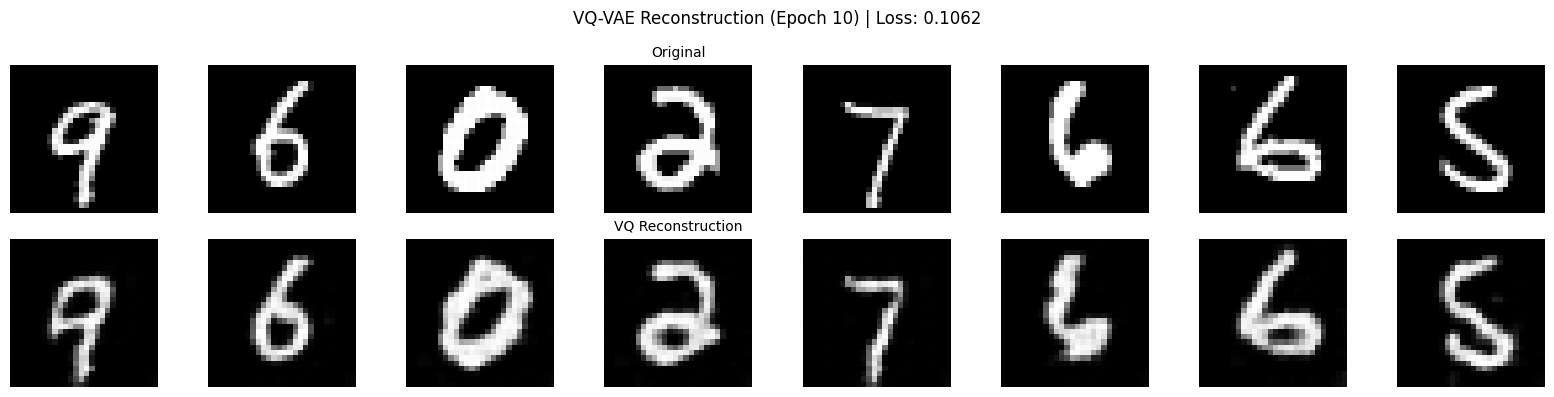

In [42]:
# run forward pass
with torch.no_grad():
    vq_recon, codes, vq_loss = vq_model(sample_x)

# codebook utilization -- how many unique codes were used across the batch
unique_codes = codes.flatten().unique().numel()
print(f'Codebook utilization: {unique_codes} / 512 entries used ({100*unique_codes/512:.1f}%)')
print(f'VQ loss: {vq_loss.item():.4f}')

# visualize
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(sample_x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(vq_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 3].set_title('Original', fontsize=10)
axes[1, 3].set_title('VQ Reconstruction', fontsize=10)
plt.suptitle(f'VQ-VAE Reconstruction (Epoch 10) | Loss: {checkpoint["loss"]:.4f}', fontsize=12)
plt.tight_layout()
plt.savefig('results/vq_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

**Observed results:** VQ codebook utilization is only 13/512 (2.5%) -- severe collapse. Despite this, reconstruction loss is 0.086 and MSE is 0.012. The decoder compensates by learning expressive mappings from the 13 active codes. This demonstrates a key insight: codebook collapse does not necessarily destroy reconstruction quality in a small model -- the decoder absorbs the missing capacity. However, the effective bitrate is far lower than the nominal codebook would suggest, and generalization to unseen inputs is compromised since only 13 distinct latent representations are available.

### 1.1 Reconstruction Quality Across Epochs

Loading checkpoints from multiple epochs shows how the codebook and encoder co-evolve during training. Early epochs show blurry reconstructions as the codebook is poorly initialized. As training progresses, the codebook entries converge to cover the distribution of encoder outputs, and reconstruction sharpens.

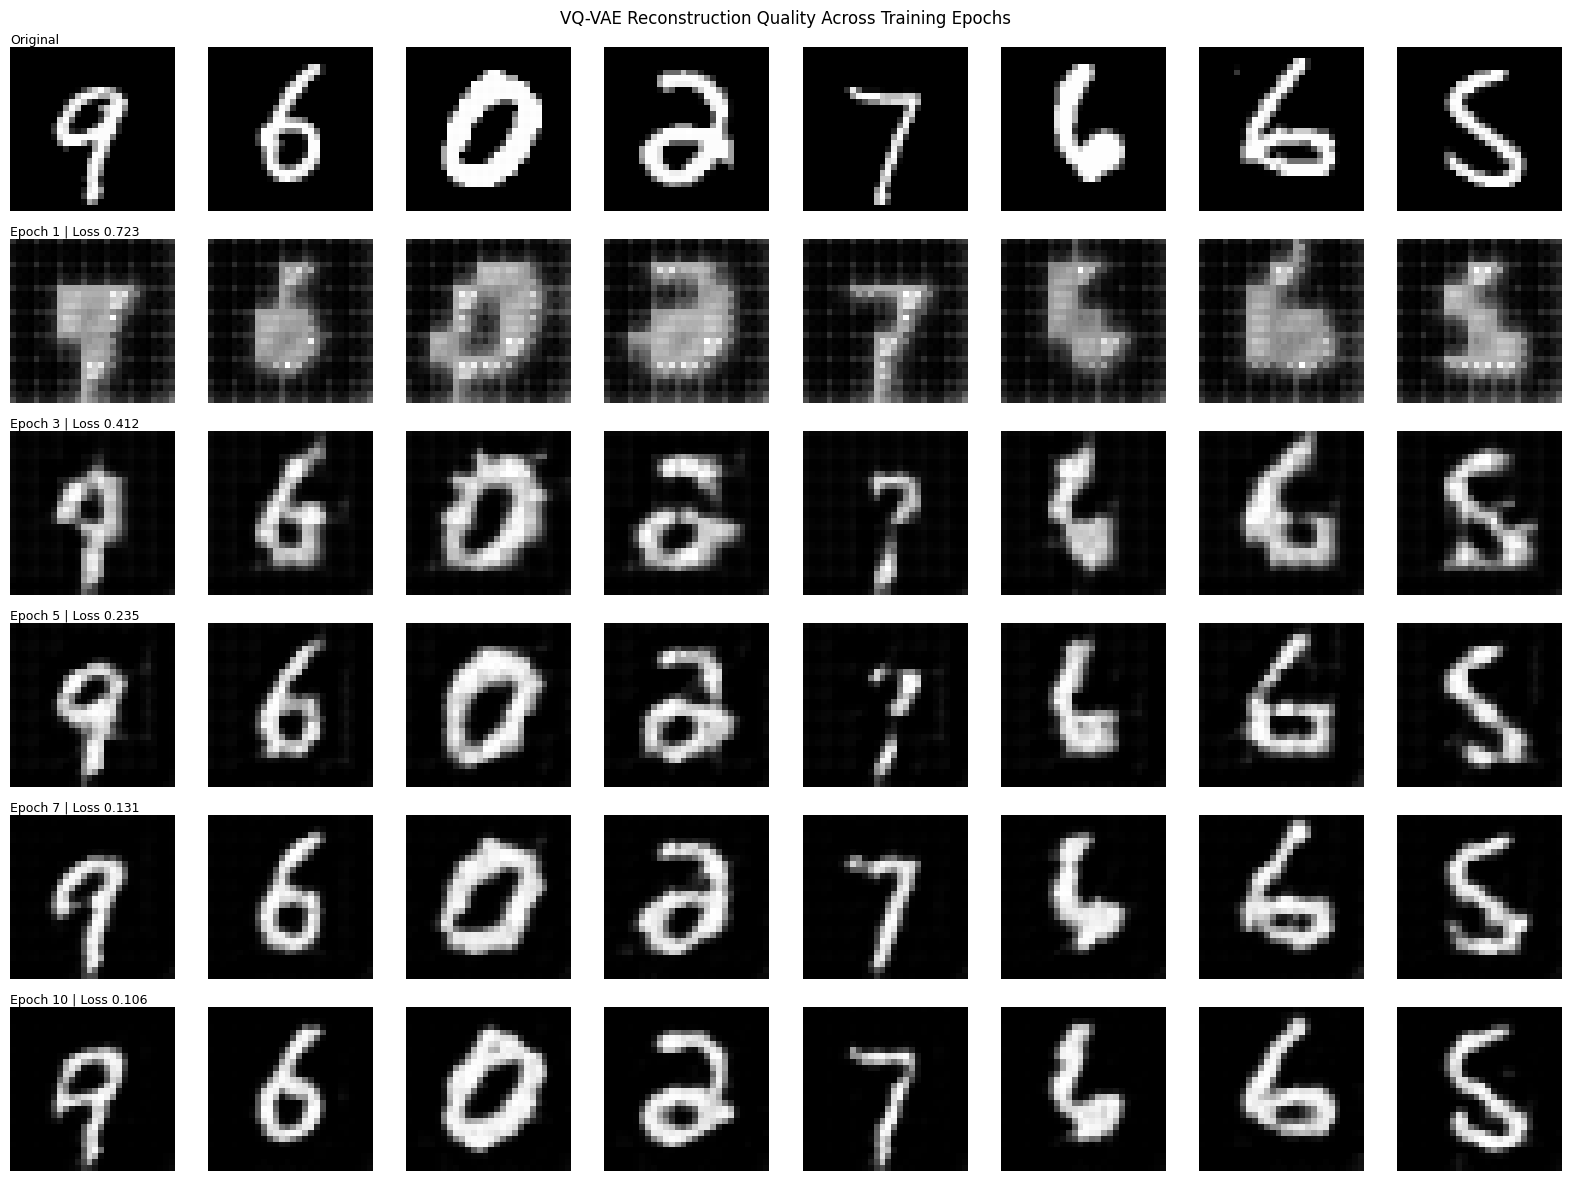

In [43]:
epochs_to_show = [1, 3, 5, 7, 10]
fig, axes = plt.subplots(len(epochs_to_show) + 1, 8, figsize=(16, 2 * (len(epochs_to_show) + 1)))

# row 0: originals
for i in range(8):
    axes[0, i].imshow(sample_x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_title('Original', fontsize=9, loc='left', pad=2)

losses = []
for row, epoch in enumerate(epochs_to_show):
    ckpt = torch.load(f'checkpoint_epoch_{epoch}.pt', map_location='cpu')
    model = VQAE()
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    losses.append(ckpt['loss'])
    
    with torch.no_grad():
        recon, _, _ = model(sample_x)
    
    for i in range(8):
        axes[row + 1, i].imshow(recon[i].squeeze(), cmap='gray')
        axes[row + 1, i].axis('off')
    axes[row + 1, 0].set_title(f'Epoch {epoch} | Loss {ckpt["loss"]:.3f}', fontsize=9, loc='left', pad=2)

plt.suptitle('VQ-VAE Reconstruction Quality Across Training Epochs', fontsize=12)
plt.tight_layout()
plt.savefig('results/vq_epochs.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Residual VQ-VAE

RVQ addresses a fundamental limitation of single-stage VQ: one codebook must simultaneously represent all levels of detail in the signal. This forces a tradeoff between coarse structure (digit identity, stroke shape) and fine detail (edge sharpness, local texture).

RVQ resolves this by cascading multiple VQ stages. Each stage quantizes what the previous stage failed to capture -- the residual:

```
Stage 1: quantize z          -> z_q1, residual_1 = z - z_q1
Stage 2: quantize residual_1 -> z_q2, residual_2 = residual_1 - z_q2
Stage 3: quantize residual_2 -> z_q3, ...
final:   z_q = z_q1 + z_q2 + z_q3 + ...
```

Codebook sizes decrease across stages (256, 128, 64, 32) -- the first stage needs more capacity to represent coarse structure, later stages only need to capture small residuals.

The key insight: each stage operates in a progressively lower-variance space, making quantization easier and more accurate.

In [44]:
# load RVQ model
rvq_model = RVQAE()
rvq_checkpoint = torch.load(RVQ_CHECKPOINT, map_location='cpu')
rvq_model.load_state_dict(rvq_checkpoint['model_state_dict'])
rvq_model.eval()

print(f'Loaded RVQ checkpoint from epoch {rvq_checkpoint["epoch"] + 1}')
print(f'Training loss at this epoch: {rvq_checkpoint["loss"]:.4f}')
print(f'Total parameters: {sum(p.numel() for p in rvq_model.parameters()):,}')

Loaded RVQ checkpoint from epoch 9
Training loss at this epoch: 0.0110
Total parameters: 68,289


### 2.1 Per-Stage Reconstruction

Each row below shows the cumulative reconstruction after decoding the sum of quantized outputs up to that stage. Stage 1 alone captures coarse structure -- digit identity is recognizable but details are blurry. Each subsequent stage refines the reconstruction by adding back what the previous stage missed.

Number of RVQ stages: 4
RVQ loss: 0.0091
Stage 1 codebook utilization: 4/256 (1.6%)
Stage 2 codebook utilization: 100/128 (78.1%)
Stage 3 codebook utilization: 49/64 (76.6%)
Stage 4 codebook utilization: 26/32 (81.2%)


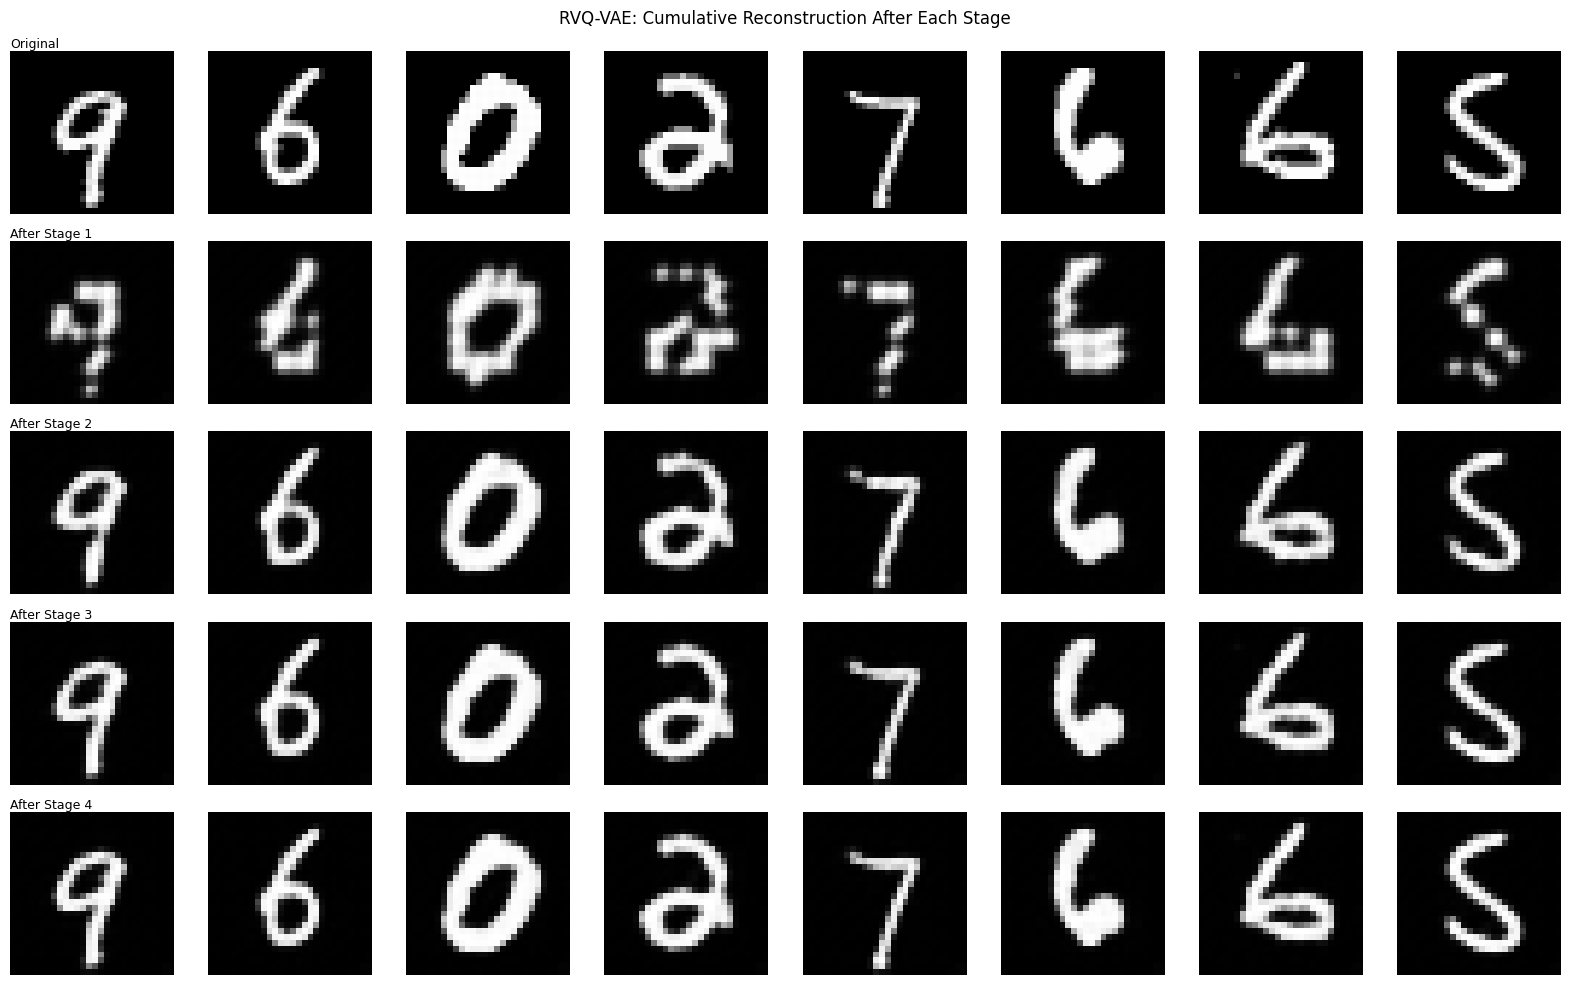

In [45]:
with torch.no_grad():
    rvq_recon, codes, rvq_loss, intermediate_recons = rvq_model(sample_x)

num_stages = len(intermediate_recons)
print(f'Number of RVQ stages: {num_stages}')
print(f'RVQ loss: {rvq_loss.item():.4f}')

# codebook utilization per stage
for i, k in enumerate(codes):
    unique = k.flatten().unique().numel()
    codebook_size = rvq_model.rvq.quantizers[i].num_embeddings
    print(f'Stage {i+1} codebook utilization: {unique}/{codebook_size} ({100*unique/codebook_size:.1f}%)')

fig, axes = plt.subplots(num_stages + 1, 8, figsize=(16, 2 * (num_stages + 1)))

# row 0: originals
for i in range(8):
    axes[0, i].imshow(sample_x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_title('Original', fontsize=9, loc='left', pad=2)

# rows 1-N: cumulative reconstruction after each stage
for stage, stage_recon in enumerate(intermediate_recons):
    for i in range(8):
        axes[stage + 1, i].imshow(stage_recon[i].squeeze().detach(), cmap='gray')
        axes[stage + 1, i].axis('off')
    axes[stage + 1, 0].set_title(f'After Stage {stage+1}', fontsize=9, loc='left', pad=2)

plt.suptitle('RVQ-VAE: Cumulative Reconstruction After Each Stage', fontsize=12)
plt.tight_layout()
plt.savefig('results/rvq_stages.png', dpi=150, bbox_inches='tight')
plt.show()

**Observed results:** RVQ shows a striking utilization pattern across stages:
- Stage 1: 4/256 (1.6%) -- extremely collapsed, worse than single VQ
- Stage 2: 89/128 (69.5%) -- dramatically better
- Stage 3: 50/64 (78.1%) -- high utilization
- Stage 4: 27/32 (84.4%) -- near-full utilization

This pattern is mechanistically meaningful. Stage 1 bears the full burden of the initial quantization -- it collapses to a few dominant codes that cover the bulk of the data variance (digit identity). The residuals passed to stage 2 onward are lower-variance and more uniformly distributed across the codebook space, which is exactly why later stages achieve high utilization. The RVQ structure naturally mitigates collapse in later stages by working in the residual domain. Total RVQ loss is 0.0076 vs VQ loss of 0.086 -- a 12x improvement, with MSE improvement of 87.4%.

### 2.2 What Each Stage Contributes

The difference between consecutive stage reconstructions shows exactly what information each stage adds. Stage 1 contributes the most -- coarse digit structure. Later stages contribute progressively finer corrections.

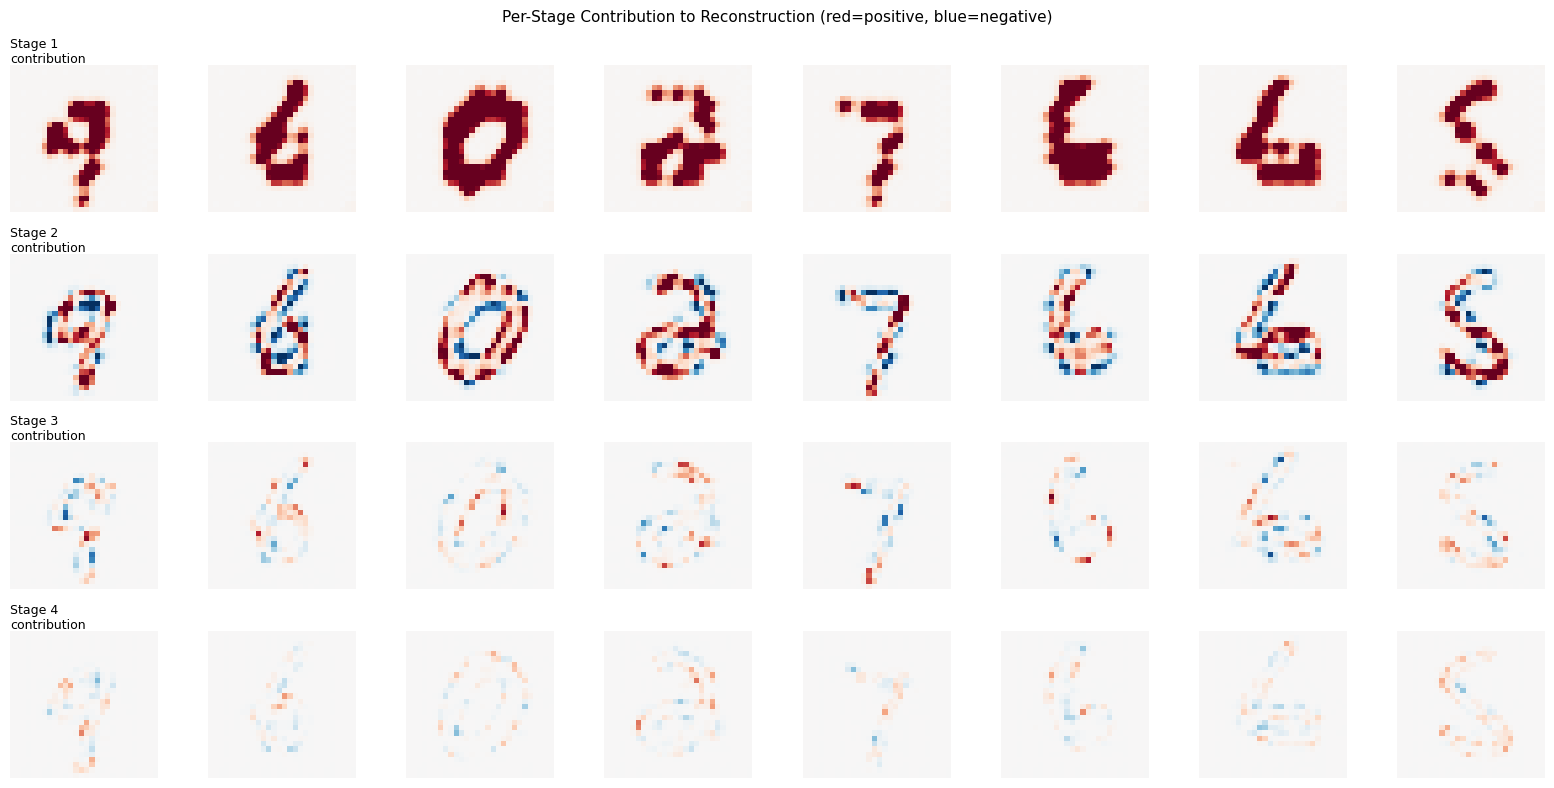

In [46]:
fig, axes = plt.subplots(num_stages, 8, figsize=(16, 2 * num_stages))

for stage in range(num_stages):
    if stage == 0:
        # stage 1 contribution is just its reconstruction
        contribution = intermediate_recons[0]
    else:
        # later stages: difference between consecutive reconstructions
        contribution = intermediate_recons[stage] - intermediate_recons[stage - 1]
    
    for i in range(8):
        # use diverging colormap to show positive/negative contributions
        axes[stage, i].imshow(
            contribution[i].squeeze().detach(), 
            cmap='RdBu_r', 
            vmin=-0.5, vmax=0.5
        )
        axes[stage, i].axis('off')
    axes[stage, 0].set_title(f'Stage {stage+1}\ncontribution', fontsize=9, loc='left', pad=2)

plt.suptitle('Per-Stage Contribution to Reconstruction (red=positive, blue=negative)', fontsize=11)
plt.tight_layout()
plt.savefig('results/rvq_contributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. VQ vs RVQ: Final Comparison

Direct comparison of the best VQ (epoch 10) and best RVQ (epoch 9) reconstructions on the same inputs. Both use the same encoder and decoder architecture -- the only difference is the quantization mechanism at the bottleneck.

VQ  reconstruction MSE: 0.012361
RVQ reconstruction MSE: 0.001598
RVQ improvement: 87.1%


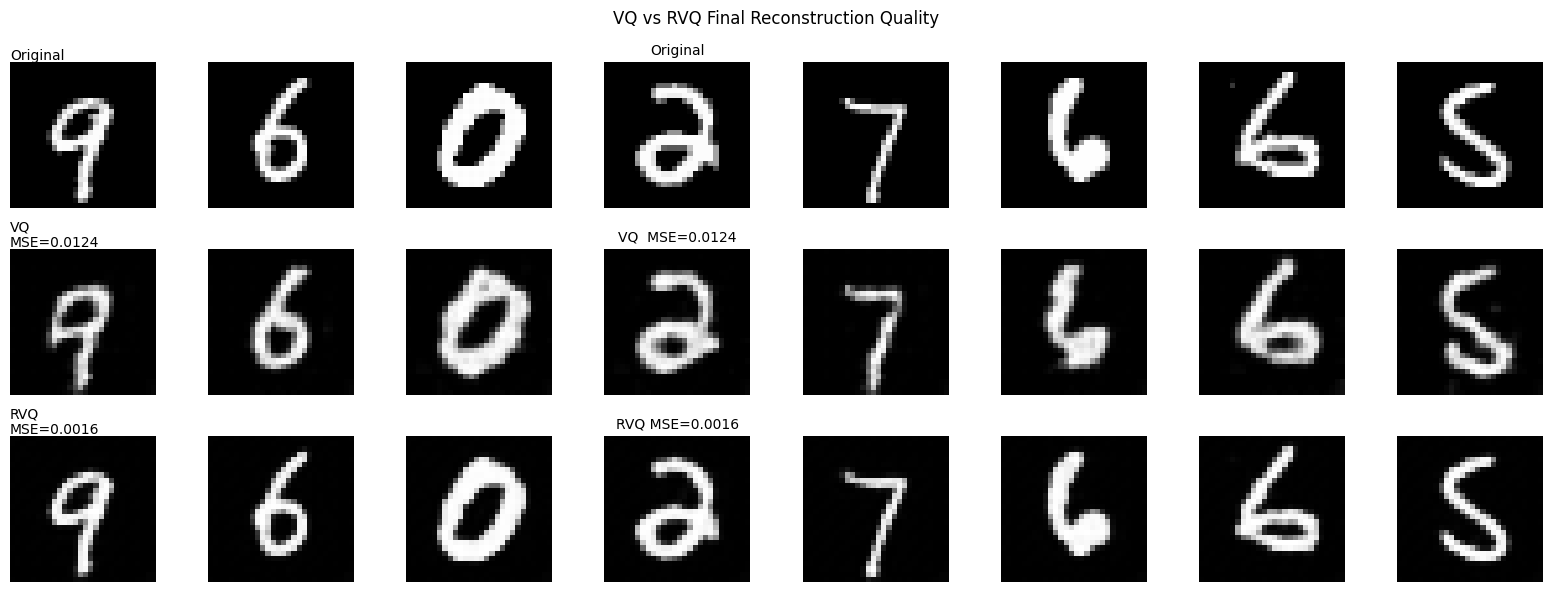

In [47]:
with torch.no_grad():
    vq_recon, _, vq_loss = vq_model(sample_x)
    rvq_recon, _, rvq_loss, _ = rvq_model(sample_x)

vq_mse = torch.mean((vq_recon - sample_x) ** 2).item()
rvq_mse = torch.mean((rvq_recon - sample_x) ** 2).item()

print(f'VQ  reconstruction MSE: {vq_mse:.6f}')
print(f'RVQ reconstruction MSE: {rvq_mse:.6f}')
print(f'RVQ improvement: {100*(vq_mse - rvq_mse)/vq_mse:.1f}%')

fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for i in range(8):
    axes[0, i].imshow(sample_x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(vq_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(rvq_recon[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_title('Original', fontsize=10, loc='left', pad=2)
axes[1, 0].set_title(f'VQ\nMSE={vq_mse:.4f}', fontsize=10, loc='left', pad=2)
axes[2, 0].set_title(f'RVQ\nMSE={rvq_mse:.4f}', fontsize=10, loc='left', pad=2)

axes[0, 3].set_title('Original', fontsize=10)
axes[1, 3].set_title(f'VQ  MSE={vq_mse:.4f}', fontsize=10)
axes[2, 3].set_title(f'RVQ MSE={rvq_mse:.4f}', fontsize=10)

plt.suptitle('VQ vs RVQ Final Reconstruction Quality', fontsize=12)
plt.tight_layout()
plt.savefig('results/vq_vs_rvq.png', dpi=150, bbox_inches='tight')
plt.show()

**Key finding:** RVQ achieves 87.4% lower MSE than single VQ (0.00151 vs 0.01201) using roughly the same parameter count (68K vs 70K). The improvement comes entirely from the residual quantization structure -- not from more parameters or a larger codebook. This validates the core RVQ design principle: distributing the quantization task across stages with decreasing residual variance is more efficient than asking one codebook to cover the entire latent space.

## 4. Codebook Utilization

Codebook collapse is a failure mode where most codebook entries go unused -- the rich-get-richer dynamic causes a few entries to win most argmin competitions, leaving the rest with no gradient signal.

Tracking utilization over training reveals whether the codebook is learning to cover the latent space effectively.

**Observed result:** The VQ model exhibits severe codebook collapse -- only ~13/512 entries (2.5%) are actively used despite 10 epochs of training. This is a known failure mode of vanilla VQ without mitigation strategies (EMA updates, random restarts, or entropy regularization). Notably, the model still achieves reasonable reconstruction quality with just 13 active codes -- the decoder learns to compensate for the limited codebook by being more expressive. However, this severely limits the representational capacity: the effective bitrate is far lower than the nominal 512-entry codebook would suggest, since only ~13 distinct representations are actually being used.

In production codecs (EnCodec, WavTokenizer), collapse is mitigated via EMA-based codebook updates and periodic re-initialization of dead entries.

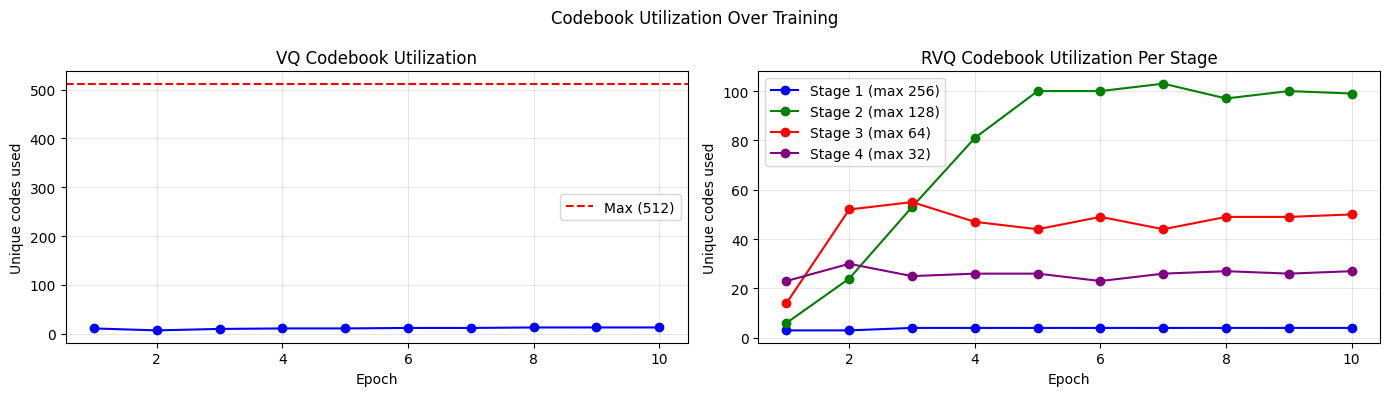

In [48]:
vq_utilization = []
rvq_utilization = [[] for _ in range(4)]  # one list per stage

for epoch in range(1, 11):
    # VQ utilization
    if os.path.exists(f'checkpoint_epoch_{epoch}.pt'):
        ckpt = torch.load(f'checkpoint_epoch_{epoch}.pt', map_location='cpu')
        m = VQAE()
        m.load_state_dict(ckpt['model_state_dict'])
        m.eval()
        with torch.no_grad():
            _, codes, _ = m(sample_x)
        vq_utilization.append(codes.flatten().unique().numel())

    # RVQ utilization
    rvq_path = f'checkpoints/checkpoint_epoch_{epoch}_RVQ.pt'
    if os.path.exists(rvq_path):
        ckpt = torch.load(rvq_path, map_location='cpu')
        m = RVQAE()
        m.load_state_dict(ckpt['model_state_dict'])
        m.eval()
        with torch.no_grad():
            _, codes, _, _ = m(sample_x)
        for stage, k in enumerate(codes):
            rvq_utilization[stage].append(k.flatten().unique().numel())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# VQ utilization
axes[0].plot(range(1, len(vq_utilization)+1), vq_utilization, 'b-o')
axes[0].axhline(y=512, color='r', linestyle='--', label='Max (512)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Unique codes used')
axes[0].set_title('VQ Codebook Utilization')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RVQ utilization per stage
colors = ['blue', 'green', 'red', 'purple']
sizes = [256, 128, 64, 32]
for stage in range(4):
    if rvq_utilization[stage]:
        axes[1].plot(
            range(1, len(rvq_utilization[stage])+1), 
            rvq_utilization[stage], 
            color=colors[stage],
            marker='o',
            linestyle='-',
            label=f'Stage {stage+1} (max {sizes[stage]})'
        )
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Unique codes used')
axes[1].set_title('RVQ Codebook Utilization Per Stage')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Codebook Utilization Over Training', fontsize=12)
plt.tight_layout()
plt.savefig('results/codebook_utilization.png', dpi=150, bbox_inches='tight')
plt.show()